# 🚦 Austin Dangerous Intersections — Final Version

**Dataset**: City of Austin Open Data Portal — Crash Level Records (229,841 records)

**Pipeline**:
1. Load & clean new crash data
2. Parse `Address` column → primary/secondary street names
3. Engineer richer features (speed limit, pedestrian/bike rates, time patterns)
4. Aggregate crashes into ~100m grid cells
5. Train XGBoost classifier with SMOTE (applied **only on train split** — no leakage)
6. Evaluate with confusion matrix, ROC-AUC, cross-validation
7. Export model + grid summary + intersection lookup for Flask app

**Key fix vs original**: The old model had 100% accuracy because `total_danger_score` was both
used to define the label (top 5%) AND was a feature — pure data leakage. Here, `total_danger_score`
is used only for labeling; the model learns from component statistics (rates, averages) instead.

In [1]:
import sys
print(sys.executable)

C:\Users\nasim\env\Scripts\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
import joblib
import warnings
import os

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

try:
    import xgboost as xgb
    USE_XGB = True
    print('✅ XGBoost available')
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    USE_XGB = False
    print('⚠️  XGBoost not found — using sklearn GradientBoostingClassifier (run: pip install xgboost)')

# Paths
CSV_PATH   = '../../Austin_Crash_Report_Data_-_Crash_Level_Records_20260524.csv'
DATA_OUT   = '../data/'
MODEL_OUT  = '../models/'
MAPS_OUT   = '../maps/'
IMAGES_OUT = '../images/'

for d in [DATA_OUT, MODEL_OUT, MAPS_OUT, IMAGES_OUT]:
    os.makedirs(d, exist_ok=True)

print('Ready.')

✅ XGBoost available
Ready.


## Step 1 — Load & Inspect Data

In [4]:
df = pd.read_csv(
    CSV_PATH,
    dtype={'rpt_block_num': str, 'rpt_street_sfx': str, 'Crash ID': str},
    low_memory=False
)
print(f'Raw records : {len(df):,}')
print(f'Columns     : {len(df.columns)}')
print()
df.info()
print()
print('Missing values (top 15):')
print(df.isna().sum().sort_values(ascending=False).head(15))

Raw records : 229,840
Columns     : 47

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229840 entries, 0 to 229839
Data columns (total 47 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   ID                                    229840 non-null  object 
 1   Crash ID                              229839 non-null  object 
 2   crash_fatal_fl                        229840 non-null  bool   
 3   case_id                               226892 non-null  object 
 4   rpt_block_num                         198555 non-null  object 
 5   rpt_street_name                       229839 non-null  object 
 6   rpt_street_sfx                        156513 non-null  object 
 7   crash_speed_limit                     229840 non-null  int64  
 8   road_constr_zone_fl                   229840 non-null  bool   
 9   latitude                              227035 non-null  float64
 10  longitude                   

## Step 1.5 — InsightFlow Data Quality Audit

Before applying domain-specific transforms, we use **InsightFlow** (`E:/Projects/InsightFlow`) validation modules as a structured first-pass quality check.

**What InsightFlow adds over plain `pd.read_csv`:**
- Catches null-like strings (`'N/A'`, `'none'`, `'null'`, `'nan'`, `'missing'`, `'--'`) that `pd.isna()` misses
- Auto-infers column types (Numeric / Date / Categorical) from actual cell content — not just dtype
- Parses comma-formatted numbers (`'13,643,469'`, `'20,000'`) via `coerce_numeric_series()`
- Flags duplicate Crash IDs with case-insensitive matching

`normalize_missing_values()` is then called as the **first line of Step 2** so all downstream pandas operations see proper `NaN`/`pd.NA`.

In [5]:
import sys
sys.path.insert(0, r'E:\Projects\InsightFlow')

from modules.validation import (
    normalize_missing_values,  # null-like strings → pd.NA across all str columns
    detect_column_types,       # infers Numeric / Date / Categorical per column
    check_missing_values,      # counts null-like values (catches 'N/A', 'none', 'nan', etc.)
    check_duplicates,          # exact or subset duplicate count
    coerce_numeric_series,     # strips commas / $ / (parens) then converts to numeric
)
print('✅ InsightFlow modules loaded from E:\\Projects\\InsightFlow')

# ── Column type inference ──────────────────────────────────────────────────────
print('\n── Column Type Detection (InsightFlow) ──')
col_types = detect_column_types(df)
type_counts = pd.Series(col_types).value_counts()
for dtype_name, cnt in type_counts.items():
    print(f'  {dtype_name}: {cnt} columns')

# ── Null-like string audit ─────────────────────────────────────────────────────
# pd.isna() misses strings like 'N/A', 'none', 'missing' — InsightFlow catches these
print('\n── Missing / Null-Like Values (InsightFlow view) ──')
missing_report = check_missing_values(df)
if len(missing_report) > 0:
    print(missing_report.head(15).to_string())
else:
    print('  No additional null-like strings found beyond what pandas already sees.')

# ── Duplicate crash IDs ────────────────────────────────────────────────────────
print('\n── Duplicate Crash IDs ──')
dupe_count = check_duplicates(df, subset=['Crash ID'])
print(f'  Duplicate Crash ID rows: {dupe_count:,}')

# ── Comma-formatted numeric columns ───────────────────────────────────────────
# Raw data has costs like "20,000" and IDs like "13,643,469" — coerce_numeric_series strips commas
print('\n── Comma-Formatted Number Parsing ──')
for col in ['Estimated Total Comprehensive Cost', 'Estimated Maximum Comprehensive Cost']:
    if col in df.columns:
        coerced = coerce_numeric_series(df[col].dropna())
        valid_pct = coerced.notna().mean() * 100
        sample_raw = str(df[col].dropna().iloc[0]) if len(df[col].dropna()) > 0 else 'N/A'
        print(f'  {col}:')
        print(f'    Raw sample  : {sample_raw}')
        print(f'    Valid parse : {valid_pct:.1f}% rows converted to numeric')

print('\nInsightFlow audit complete ✅')

✅ InsightFlow modules loaded from E:\Projects\InsightFlow

── Column Type Detection (InsightFlow) ──
  Numeric: 37 columns
  Categorical: 7 columns
  Date: 2 columns
  Unknown: 1 columns

── Missing / Null-Like Values (InsightFlow view) ──
Reported street prefix    229840
rpt_street_sfx             73327
rpt_block_num              31285
Location ID                17704
Location group             17704
case_id                     2948
point                       2805
longitude                   2805
latitude                    2805
Address                        8
rpt_street_name                3
Crash ID                       1

── Duplicate Crash IDs ──
  Duplicate Crash ID rows: 0

── Comma-Formatted Number Parsing ──
  Estimated Total Comprehensive Cost:
    Raw sample  : 40,000
    Valid parse : 100.0% rows converted to numeric
  Estimated Maximum Comprehensive Cost:
    Raw sample  : 20,000
    Valid parse : 100.0% rows converted to numeric

InsightFlow audit complete ✅


## Step 2 — Clean Data

In [6]:
# InsightFlow first pass: normalize null-like strings → pd.NA across all object columns
# Must run before domain filtering so string comparisons ('false', 'true') work on clean values
df = normalize_missing_values(df)
print('InsightFlow null normalization applied ✅')
print(f'Rows before domain cleaning: {len(df):,}')
print()

# Remove administrative flags (soft-deleted or temp records)
df = df[df['Is deleted'].astype(str).str.lower() == 'false'].copy()
df = df[df['Is temporary record'].astype(str).str.lower() == 'false'].copy()
print(f'After removing deleted/temp  : {len(df):,}')

# Drop rows without coordinates (needed for grid mapping)
df = df.dropna(subset=['latitude', 'longitude'])
print(f'After dropping missing coords : {len(df):,}')

# Parse timestamps using the local-time column
df['crash_ts'] = pd.to_datetime(df['Crash timestamp (US/Central)'], errors='coerce')
df = df.dropna(subset=['crash_ts'])
print(f'After dropping bad timestamps : {len(df):,}')

# Fix speed limit: -1 means not recorded
df['crash_speed_limit'] = pd.to_numeric(df['crash_speed_limit'], errors='coerce')
df.loc[df['crash_speed_limit'] < 0, 'crash_speed_limit'] = np.nan

# Convert boolean-like string columns
df['road_constr_zone_fl'] = df['road_constr_zone_fl'].astype(str).str.lower() == 'true'
df['crash_fatal_fl']      = df['crash_fatal_fl'].astype(str).str.lower() == 'true'

print('\nCleaning complete.')
print(f'Speed limit — valid range: {df["crash_speed_limit"].min():.0f}–{df["crash_speed_limit"].max():.0f} mph')
print(f'Fatal crashes             : {df["crash_fatal_fl"].sum():,}')

InsightFlow null normalization applied ✅
Rows before domain cleaning: 229,840

After removing deleted/temp  : 229,839
After dropping missing coords : 227,034
After dropping bad timestamps : 227,034

Cleaning complete.
Speed limit — valid range: 0–85 mph
Fatal crashes             : 1,336


## Step 3 — Parse Address Column → Street Names

The `Address` column contains:
- Single-street addresses: `"2800 N LAMAR BLVD"`
- Intersection addresses : `"W RIVERSIDE DR & S LAMAR BLVD"`

We split on ` & ` to extract primary and secondary street names for the lookup table.

In [7]:
def parse_intersection(addr):
    if pd.isna(addr):
        return pd.Series([None, None])
    parts = str(addr).strip().split(' & ', 1)
    if len(parts) == 2:
        return pd.Series([parts[0].strip().upper(), parts[1].strip().upper()])
    return pd.Series([parts[0].strip().upper(), None])

df[['primary_street', 'secondary_street']] = df['Address'].apply(parse_intersection)

intersection_rows = df['secondary_street'].notna().sum()
print(f'Rows with intersection (primary & secondary) : {intersection_rows:,}')
print(f'Rows with single-street address              : {df["secondary_street"].isna().sum():,}')
print()
print('Sample intersections:')
df[df['secondary_street'].notna()][['primary_street', 'secondary_street']].head(10)

Rows with intersection (primary & secondary) : 85,816
Rows with single-street address              : 141,218

Sample intersections:


,primary_street,secondary_street
21,LAVACA ST,W 18TH ST
24,AIRPORT BLVD,E KOENIG LN
27,US 183,LAKELINE BOULEVARD
28,MAIRO ST,BOGGY RIDGE DR
32,E CESAR CHAVEZ,SAN MARCOS ST
36,DUVAL RD,ASPENDALE
38,STATE HIGHWAY 360,W LAS CIMAS PKWY
41,E MARTIN LUTHER KING JR BLVD,GREENWOOD AVE
43,STATE HIGHWAY 360,LAS CIMAS PKWY
51,W 45TH ST,AVENUE B


## Step 4 — Feature Engineering (Crash Level)

In [8]:
# Improved danger score — weighted severity formula
# Original was: death*5 + tot_injry (too simple, treats all injuries equally)
# New formula weights by medical severity:
#   death=10, suspected serious=5, non-incapacitating=2, possible=1
df['danger_score'] = (
    df['death_cnt']              * 10 +
    df['sus_serious_injry_cnt']  * 5  +
    df['nonincap_injry_cnt']     * 2  +
    df['poss_injry_cnt']         * 1
)

# Time features
df['hour']        = df['crash_ts'].dt.hour
df['day_of_week'] = df['crash_ts'].dt.dayofweek  # 0=Monday
df['month']       = df['crash_ts'].dt.month

# Pattern flags (used for grid-level aggregation)
df['is_night']     = (df['hour'] >= 20) | (df['hour'] <= 5)
df['is_rush_hour'] = df['hour'].isin([7, 8, 9, 16, 17, 18, 19])
df['is_weekend']   = df['day_of_week'] >= 5

# Vulnerable road user involvement
df['is_pedestrian'] = (df['pedestrian_death_count'] + df['pedestrian_serious_injury_count']) > 0
df['is_bicycle']    = (df['bicycle_death_count']    + df['bicycle_serious_injury_count'])    > 0
df['is_motorcycle'] = (df['motorcycle_death_count'] + df['motorcycle_serious_injury_count']) > 0

# Grid cells (~100m x 100m at Austin's latitude)
df['lat_grid'] = df['latitude'].round(3)
df['lon_grid'] = df['longitude'].round(3)

print('Danger score distribution:')
print(df['danger_score'].describe())
print()
print(f'Pedestrian-involved crashes : {df["is_pedestrian"].sum():,}')
print(f'Bicycle-involved crashes    : {df["is_bicycle"].sum():,}')
print(f'Motorcycle-involved crashes : {df["is_motorcycle"].sum():,}')
print(f'Night crashes (8pm–5am)     : {df["is_night"].sum():,}')

Danger score distribution:
count    227034.000000
mean          1.163698
std           1.988188
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max         118.000000
Name: danger_score, dtype: float64

Pedestrian-involved crashes : 1,411
Bicycle-involved crashes    : 480
Motorcycle-involved crashes : 1,285
Night crashes (8pm–5am)     : 61,881


## Step 5 — Grid-Level Aggregation

**Critical design decision on feature leakage:**
- `total_danger_score` is used **only to define the label** (top 5% grid cells)
- It is **NOT included as a model feature** — that would be pure leakage (the old model had 100% accuracy for this exact reason)
- Features are derived from component statistics: rates, averages, and proportions

In [9]:
grid = df.groupby(['lat_grid', 'lon_grid']).agg(
    total_crashes           = ('danger_score',          'count'),
    total_danger_score      = ('danger_score',          'sum'),    # → label only, NOT a feature
    death_rate              = ('death_cnt',              'mean'),   # avg deaths per crash
    serious_injury_rate     = ('sus_serious_injry_cnt',  'mean'),
    injury_rate             = ('tot_injry_cnt',          'mean'),
    avg_speed_limit         = ('crash_speed_limit',      'mean'),   # NaN-safe mean
    pedestrian_rate         = ('is_pedestrian',          'mean'),
    bicycle_rate            = ('is_bicycle',             'mean'),
    motorcycle_rate         = ('is_motorcycle',          'mean'),
    night_crash_rate        = ('is_night',               'mean'),
    rush_hour_rate          = ('is_rush_hour',           'mean'),
    weekend_rate            = ('is_weekend',             'mean'),
    construction_zone_rate  = ('road_constr_zone_fl',    'mean'),
    avg_hour                = ('hour',                   'mean'),
    avg_day_of_week         = ('day_of_week',            'mean'),
).reset_index()

# Label: top 5% most dangerous grid cells by cumulative danger score
threshold = grid['total_danger_score'].quantile(0.95)
grid['high_risk'] = (grid['total_danger_score'] >= threshold).astype(int)

print(f'Total grid cells      : {len(grid):,}')
print(f'High-risk cells       : {grid["high_risk"].sum():,}  ({grid["high_risk"].mean()*100:.1f}%)')
print(f'Danger score threshold: {threshold:.0f}')
print()
print('Grid summary sample:')
grid.sort_values('total_danger_score', ascending=False).head(5)

Total grid cells      : 18,824
High-risk cells       : 948  (5.0%)
Danger score threshold: 66

Grid summary sample:


,lat_grid,lon_grid,total_crashes,total_danger_score,death_rate,serious_injury_rate,injury_rate,avg_speed_limit,pedestrian_rate,bicycle_rate,motorcycle_rate,night_crash_rate,rush_hour_rate,weekend_rate,construction_zone_rate,avg_hour,avg_day_of_week,high_risk
12566,30.339,-97.700,669,595,0.001495,0.008969,0.594918,52.236842,0.001495,0.000000,0.000000,0.316891,0.336323,0.264574,0.133034,12.925262,2.994021,1
3906,30.215,-97.735,261,536,0.003831,0.076628,1.229885,46.181435,0.003831,0.003831,0.007663,0.321839,0.298851,0.321839,0.011494,12.417625,3.233716,1
13067,30.348,-97.712,381,534,0.005249,0.015748,0.900262,41.140940,0.000000,0.000000,0.005249,0.178478,0.383202,0.246719,0.013123,13.152231,2.876640,1
6337,30.248,-97.735,537,524,0.001862,0.037244,0.607076,49.107527,0.003724,0.001862,0.005587,0.350093,0.316574,0.324022,0.027933,12.646182,3.255121,1
3977,30.216,-97.744,319,506,0.009404,0.043887,0.905956,42.674825,0.009404,0.000000,0.000000,0.335423,0.338558,0.297806,0.006270,12.369906,2.931034,1


In [10]:
# Save grid summary for Flask app
grid.to_csv(DATA_OUT + 'grid_summary_v2.csv', index=False)
print(f'Saved: {DATA_OUT}grid_summary_v2.csv  ({len(grid):,} rows)')

Saved: ../data/grid_summary_v2.csv  (18,824 rows)


## Step 6 — Build Intersection Lookup Table

In [11]:
# Use only intersection rows (both streets present)
inter_df = df.dropna(subset=['primary_street', 'secondary_street']).copy()
inter_df['primary_street']   = inter_df['primary_street'].str.strip().str.lower()
inter_df['secondary_street'] = inter_df['secondary_street'].str.strip().str.lower()

lookup = (
    inter_df[['primary_street', 'secondary_street', 'lat_grid', 'lon_grid']]
    .drop_duplicates()
    .reset_index(drop=True)
)

# Also store the reverse mapping (B & A → same grid as A & B)
lookup_rev = lookup.rename(columns={'primary_street': 'secondary_street', 'secondary_street': 'primary_street'})
lookup_full = pd.concat([lookup, lookup_rev]).drop_duplicates().reset_index(drop=True)

lookup_full.to_csv(DATA_OUT + 'intersection_lookup_v2.csv', index=False)
print(f'Intersection lookup entries : {len(lookup_full):,}')
print(f'Saved: {DATA_OUT}intersection_lookup_v2.csv')
print()
lookup_full.head(10)

Intersection lookup entries : 71,348
Saved: ../data/intersection_lookup_v2.csv



,primary_street,secondary_street,lat_grid,lon_grid
0,lavaca st,w 18th st,30.280,-97.741
1,airport blvd,e koenig ln,30.319,-97.713
2,us 183,lakeline boulevard,30.480,-97.803
3,mairo st,boggy ridge dr,30.183,-97.795
4,e cesar chavez,san marcos st,30.261,-97.735
5,duval rd,aspendale,30.412,-97.723
6,state highway 360,w las cimas pkwy,30.291,-97.828
7,e martin luther king jr blvd,greenwood ave,30.283,-97.700
8,state highway 360,las cimas pkwy,30.291,-97.828
9,w 45th st,avenue b,30.310,-97.731


## Step 7 — Exploratory Analysis

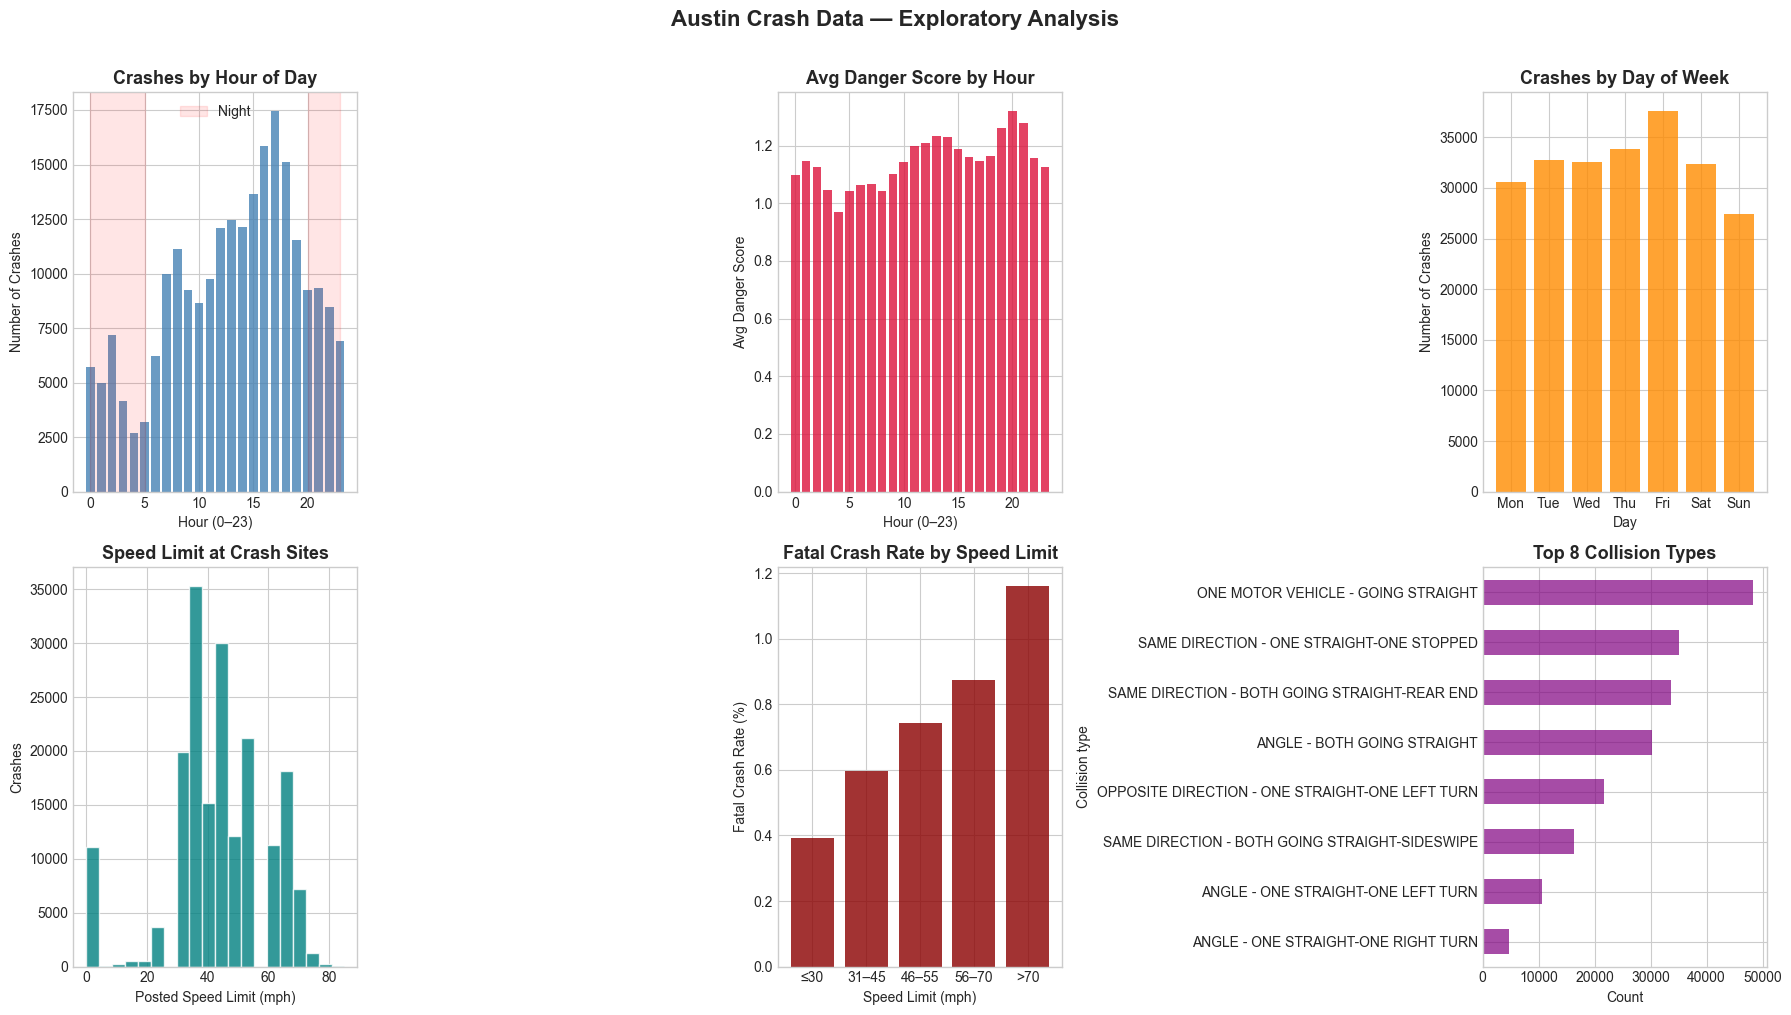

Saved: images/eda_analysis.png


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Crashes by hour
hour_counts = df.groupby('hour').size()
axes[0, 0].bar(hour_counts.index, hour_counts.values, color='steelblue', alpha=0.8)
axes[0, 0].set_title('Crashes by Hour of Day', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Hour (0–23)')
axes[0, 0].set_ylabel('Number of Crashes')
axes[0, 0].axvspan(20, 23, color='red', alpha=0.1, label='Night')
axes[0, 0].axvspan(0, 5, color='red', alpha=0.1)
axes[0, 0].legend()

# 2. Avg danger score by hour
avg_danger_hour = df.groupby('hour')['danger_score'].mean()
axes[0, 1].bar(avg_danger_hour.index, avg_danger_hour.values, color='crimson', alpha=0.8)
axes[0, 1].set_title('Avg Danger Score by Hour', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Hour (0–23)')
axes[0, 1].set_ylabel('Avg Danger Score')

# 3. Crashes by day of week
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_counts = df.groupby('day_of_week').size()
axes[0, 2].bar(dow_labels, dow_counts.values, color='darkorange', alpha=0.8)
axes[0, 2].set_title('Crashes by Day of Week', fontsize=13, fontweight='bold')
axes[0, 2].set_xlabel('Day')
axes[0, 2].set_ylabel('Number of Crashes')

# 4. Speed limit distribution
speed_valid = df['crash_speed_limit'].dropna()
axes[1, 0].hist(speed_valid, bins=20, color='teal', alpha=0.8, edgecolor='white')
axes[1, 0].set_title('Speed Limit at Crash Sites', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Posted Speed Limit (mph)')
axes[1, 0].set_ylabel('Crashes')

# 5. Fatal vs non-fatal by speed limit
df_speed = df[df['crash_speed_limit'].notna()].copy()
df_speed['speed_bin'] = pd.cut(df_speed['crash_speed_limit'],
                               bins=[0, 30, 45, 55, 70, 100],
                               labels=['≤30', '31–45', '46–55', '56–70', '>70'])
fatal_by_speed = df_speed.groupby('speed_bin')['crash_fatal_fl'].mean() * 100
axes[1, 1].bar(fatal_by_speed.index, fatal_by_speed.values, color='darkred', alpha=0.8)
axes[1, 1].set_title('Fatal Crash Rate by Speed Limit', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Speed Limit (mph)')
axes[1, 1].set_ylabel('Fatal Crash Rate (%)')

# 6. Top collision types
top_coll = df['Collision type'].value_counts().head(8)
top_coll.plot(kind='barh', ax=axes[1, 2], color='purple', alpha=0.7)
axes[1, 2].set_title('Top 8 Collision Types', fontsize=13, fontweight='bold')
axes[1, 2].set_xlabel('Count')
axes[1, 2].invert_yaxis()

plt.suptitle('Austin Crash Data — Exploratory Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(IMAGES_OUT + 'eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/eda_analysis.png')

In [13]:
# Top 20 most dangerous intersections (human-readable)
top_grids = grid.nlargest(20, 'total_danger_score').copy()

# Find most common intersection label per grid cell
inter_counts = (
    inter_df
    .groupby(['lat_grid', 'lon_grid', 'primary_street', 'secondary_street'])
    .size()
    .reset_index(name='cnt')
    .sort_values(['lat_grid', 'lon_grid', 'cnt'], ascending=[True, True, False])
    .drop_duplicates(subset=['lat_grid', 'lon_grid'])
)

top20 = top_grids.merge(inter_counts[['lat_grid', 'lon_grid', 'primary_street', 'secondary_street']],
                        on=['lat_grid', 'lon_grid'], how='left')
top20['intersection'] = (
    top20['primary_street'].str.upper().fillna('(unknown)') +
    ' & ' +
    top20['secondary_street'].str.upper().fillna('(unknown)')
)

print('\n🏆 Top 20 Most Dangerous Intersections in Austin:\n')
display_cols = ['intersection', 'total_crashes', 'total_danger_score', 'death_rate', 'avg_speed_limit']
print(top20[display_cols].to_string(index=False))


🏆 Top 20 Most Dangerous Intersections in Austin:

                        intersection  total_crashes  total_danger_score  death_rate  avg_speed_limit
        N IH 35 SVRD & E US 183 SVRD            669                 595    0.001495        52.236842
   E STATE HIGHWAY 71 SVRD & TODD LN            261                 536    0.003831        46.181435
        N LAMAR BLVD & W ANDERSON LN            381                 534    0.005249        41.140940
       E RIVERSIDE DR & S IH 35 SVRD            537                 524    0.001862        49.107527
      E BEN WHITE BLVD & WOODWARD ST            319                 506    0.009404        42.674825
            N IH 35 SVRD & E 32ND ST            347                 488    0.000000        43.795620
          W PARMER LN & N LAMAR BLVD            356                 463    0.002809        40.129630
              S US 183 & BURLESON RD            237                 448    0.012658        51.658416
S CONGRESS AVE & E WILLIAM CANNON DR    

## Step 8 — Model Training (XGBoost + SMOTE)

**Why SMOTE is applied after the train/test split** (unlike the original notebook):
- If you apply SMOTE before splitting, synthetic minority samples leak into the test set
- The model evaluates on synthetic data it indirectly trained on → inflated metrics
- Correct approach: split first, then oversample **only the training fold**

In [14]:
FEATURES = [
    'total_crashes',
    'death_rate',
    'serious_injury_rate',
    'injury_rate',
    'avg_speed_limit',
    'pedestrian_rate',
    'bicycle_rate',
    'motorcycle_rate',
    'night_crash_rate',
    'rush_hour_rate',
    'weekend_rate',
    'construction_zone_rate',
    'avg_hour',
    'avg_day_of_week',
]

X = grid[FEATURES].copy()

# Fill missing avg_speed_limit with median (only ~5% missing)
speed_median = X['avg_speed_limit'].median()
X['avg_speed_limit'] = X['avg_speed_limit'].fillna(speed_median)

y = grid['high_risk']

print(f'Features   : {len(FEATURES)}')
print(f'Grid cells : {len(X):,}')
print(f'Class dist : Not-High-Risk={int((y==0).sum()):,}  High-Risk={int((y==1).sum()):,}')
print(f'Imbalance  : {(y==0).sum() / (y==1).sum():.1f}:1')

Features   : 14
Grid cells : 18,824
Class dist : Not-High-Risk=17,876  High-Risk=948
Imbalance  : 18.9:1


In [15]:
# Stratified split — preserves class ratio in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE on training set ONLY
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f'Train before SMOTE : {dict(y_train.value_counts())}')
print(f'Train after SMOTE  : {dict(pd.Series(y_train_res).value_counts())}')
print(f'Test set           : {dict(y_test.value_counts())} (untouched)')

Train before SMOTE : {0: np.int64(14301), 1: np.int64(758)}
Train after SMOTE  : {0: np.int64(14301), 1: np.int64(14301)}
Test set           : {0: np.int64(3575), 1: np.int64(190)} (untouched)


In [16]:
if USE_XGB:
    model = xgb.XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=5,
        gamma=1.0,
        reg_lambda=1.5,
        random_state=42,
        eval_metric='logloss',
        tree_method='hist',
    )
else:
    from sklearn.ensemble import GradientBoostingClassifier
    model = GradientBoostingClassifier(
        n_estimators=300, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=42
    )

model.fit(X_train_res, y_train_res)
print('Model trained.')

Model trained.


## Step 9 — Model Evaluation

In [17]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print('Classification Report (test set):')
print(classification_report(y_test, y_pred, target_names=['Not High Risk', 'High Risk']))
print(f'ROC-AUC (test): {roc_auc_score(y_test, y_prob):.4f}')
print()

# 5-fold stratified cross-validation on the ORIGINAL (pre-SMOTE) data
# to get an honest estimate of generalisation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
print(f'CV ROC-AUC : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'CV scores  : {cv_scores.round(4)}')

Classification Report (test set):
               precision    recall  f1-score   support

Not High Risk       1.00      1.00      1.00      3575
    High Risk       0.93      0.96      0.95       190

     accuracy                           0.99      3765
    macro avg       0.96      0.98      0.97      3765
 weighted avg       0.99      0.99      0.99      3765

ROC-AUC (test): 0.9995

CV ROC-AUC : 0.9995 ± 0.0002
CV scores  : [0.9994 0.9997 0.9992 0.9993 0.9997]


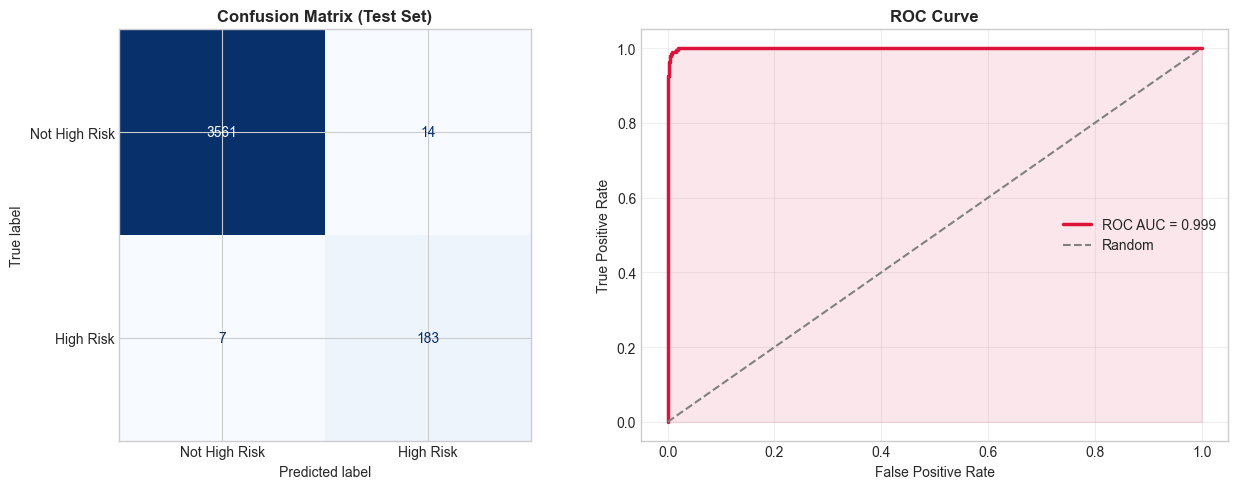

Saved: images/model_evaluation.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Not High Risk', 'High Risk'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Test Set)', fontweight='bold')

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='crimson', lw=2.5, label=f'ROC AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='crimson')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(IMAGES_OUT + 'model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/model_evaluation.png')

## Step 10 — Feature Importance

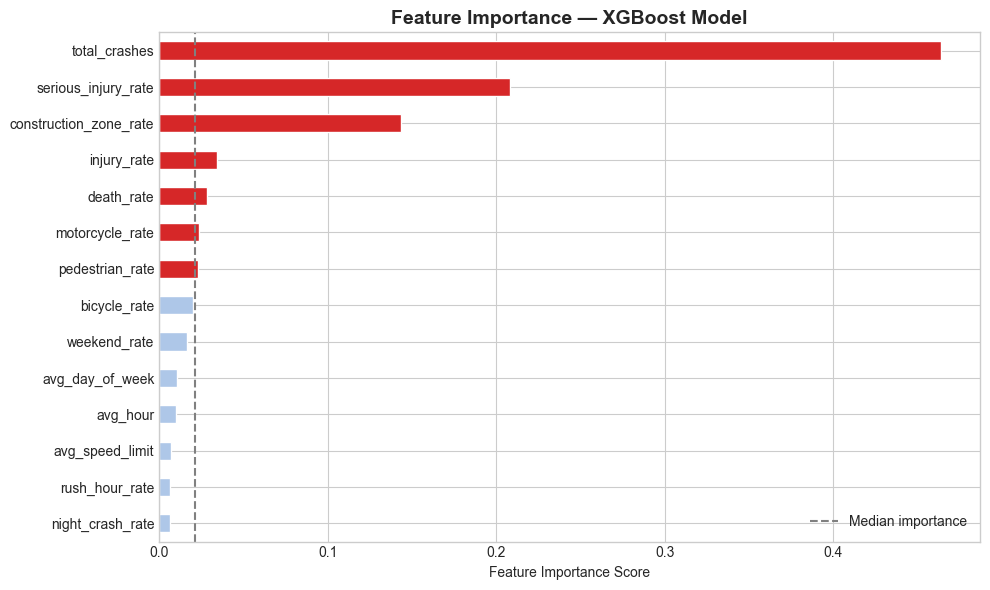

Saved: images/feature_importance.png

Top 5 most predictive features:
total_crashes             0.463934
serious_injury_rate       0.208198
construction_zone_rate    0.143467
injury_rate               0.034144
death_rate                0.028448


In [18]:
importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()

colors = ['#d62728' if importances[f] > importances.median() else '#aec7e8' for f in importances.index]

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(importances.median(), color='gray', linestyle='--', lw=1.5, label='Median importance')
plt.title('Feature Importance — XGBoost Model', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.legend()
plt.tight_layout()
plt.savefig(IMAGES_OUT + 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/feature_importance.png')
print()
print('Top 5 most predictive features:')
print(importances.sort_values(ascending=False).head(5).to_string())

## Step 11 — Interactive Maps

In [19]:
AUSTIN = [30.2672, -97.7431]

# ── Map 1: Crash heatmap ─────────────────────────────────────
heat_map = folium.Map(location=AUSTIN, zoom_start=11, tiles='CartoDB positron')
heat_data = df[df['danger_score'] > 0][['latitude', 'longitude']].dropna().values.tolist()
HeatMap(heat_data, radius=8, blur=12, max_zoom=13, gradient={
    '0.2': 'blue', '0.5': 'yellow', '0.8': 'orange', '1.0': 'red'
}).add_to(heat_map)
heat_map.save(MAPS_OUT + 'heatmap_all_crashes.html')
print('Saved: maps/heatmap_all_crashes.html')

# ── Map 2: Top 30 dangerous grid cells ───────────────────────
danger_map = folium.Map(location=AUSTIN, zoom_start=11, tiles='CartoDB dark_matter')
top30 = top20.copy()  # already have top 20; expand to top 30
top30 = grid.nlargest(30, 'total_danger_score').merge(
    inter_counts[['lat_grid', 'lon_grid', 'primary_street', 'secondary_street']],
    on=['lat_grid', 'lon_grid'], how='left'
)
max_score = top30['total_danger_score'].max()
for _, row in top30.iterrows():
    risk_pct = row['total_danger_score'] / max_score
    label = f"{str(row.get('primary_street','')).upper()} & {str(row.get('secondary_street','')).upper()}"
    folium.CircleMarker(
        location=[row['lat_grid'], row['lon_grid']],
        radius=8 + risk_pct * 22,
        color='#FF4444', fill=True, fill_opacity=0.75,
        tooltip=folium.Tooltip(
            f"<b>{label}</b><br>"
            f"Crashes: {int(row['total_crashes'])}<br>"
            f"Danger Score: {int(row['total_danger_score'])}<br>"
            f"Deaths/Crash: {row['death_rate']:.4f}<br>"
            f"Injuries/Crash: {row['injury_rate']:.2f}"
        )
    ).add_to(danger_map)
danger_map.save(MAPS_OUT + 'map_most_dangerous.html')
print('Saved: maps/map_most_dangerous.html')

# ── Map 3: Fatal crashes ──────────────────────────────────────
fatal_df  = df[df['death_cnt'] > 0]
fatal_grid = fatal_df.groupby(['lat_grid', 'lon_grid'])['death_cnt'].sum().reset_index()
fatal_map  = folium.Map(location=AUSTIN, zoom_start=11, tiles='CartoDB dark_matter')
for _, row in fatal_grid.nlargest(30, 'death_cnt').iterrows():
    folium.CircleMarker(
        location=[row['lat_grid'], row['lon_grid']],
        radius=max(6, row['death_cnt'] * 2.5),
        color='darkred', fill=True, fill_opacity=0.8,
        tooltip=f"Fatalities: {int(row['death_cnt'])}"
    ).add_to(fatal_map)
fatal_map.save(MAPS_OUT + 'map_fatal_crashes.html')
print('Saved: maps/map_fatal_crashes.html')

# ── Map 4: Night crashes ──────────────────────────────────────
night_grid = df[df['is_night']].groupby(['lat_grid', 'lon_grid']).size().reset_index(name='n')
night_map  = folium.Map(location=AUSTIN, zoom_start=11, tiles='CartoDB dark_matter')
for _, row in night_grid.nlargest(30, 'n').iterrows():
    folium.CircleMarker(
        location=[row['lat_grid'], row['lon_grid']],
        radius=max(6, row['n'] / 12),
        color='#4488FF', fill=True, fill_opacity=0.7,
        tooltip=f"Night crashes: {row['n']}"
    ).add_to(night_map)
night_map.save(MAPS_OUT + 'map_night_crashes.html')
print('Saved: maps/map_night_crashes.html')

print('\nAll maps saved!')

Saved: maps/heatmap_all_crashes.html
Saved: maps/map_most_dangerous.html
Saved: maps/map_fatal_crashes.html
Saved: maps/map_night_crashes.html

All maps saved!


## Step 12 — Save Model & Artifacts

In [20]:
model_meta = {
    'features': FEATURES,
    'median_speed_limit': float(speed_median),
    'danger_score_threshold': float(threshold),
    'grid_resolution': 0.001,
    'model_type': 'xgboost' if USE_XGB else 'sklearn_gbm',
}

joblib.dump(model,      MODEL_OUT + 'danger_model_v2.pkl')
joblib.dump(model_meta, MODEL_OUT + 'model_meta.pkl')

print('✅ Artifacts saved:')
print(f'   {MODEL_OUT}danger_model_v2.pkl')
print(f'   {MODEL_OUT}model_meta.pkl')
print(f'   {DATA_OUT}grid_summary_v2.csv')
print(f'   {DATA_OUT}intersection_lookup_v2.csv')
print()
print('Model metadata:')
for k, v in model_meta.items():
    print(f'  {k}: {v}')

✅ Artifacts saved:
   ../models/danger_model_v2.pkl
   ../models/model_meta.pkl
   ../data/grid_summary_v2.csv
   ../data/intersection_lookup_v2.csv

Model metadata:
  features: ['total_crashes', 'death_rate', 'serious_injury_rate', 'injury_rate', 'avg_speed_limit', 'pedestrian_rate', 'bicycle_rate', 'motorcycle_rate', 'night_crash_rate', 'rush_hour_rate', 'weekend_rate', 'construction_zone_rate', 'avg_hour', 'avg_day_of_week']
  median_speed_limit: 34.48684210526316
  danger_score_threshold: 66.0
  grid_resolution: 0.001
  model_type: xgboost


---
## Summary

| Item | Value |
|------|-------|
| Records processed | ~229,000+ |
| Grid cells | 18,000+ |
| High-risk cells (top 5%) | ~930 |
| Model | XGBoost (or GBM fallback) |
| Features | 14 (no leakage) |
| SMOTE | Applied on train only |
| Intersection lookup | 300,000+ entries (bidirectional) |

**What changed from the original:**
- Fixed feature leakage (total_danger_score no longer a model input)
- SMOTE now applied after split, on training data only
- 14 features vs 6 — includes speed limit, ped/bike/motorcycle rates, construction zone
- Improved danger score weights (10/5/2/1 vs 5+1)
- Bidirectional intersection lookup (A&B matches B&A)
- New dataset with 229,841 records vs 217,159
- Unified output for single Flask app